<a href="https://colab.research.google.com/github/AnanyarajS/neuro_symbolic_ai/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Pneumonia Detection with DenseNet121 + Grad-CAM (Production-Ready)
# Improvements: Overfitting fix, proper transforms, Mixup, Captum Grad-CAM

# ===== 1. SETUP & DATA DOWNLOAD =====
import os
os.environ['KAGGLE_USERNAME'] = 'ananyarajshekhar'
os.environ['KAGGLE_KEY'] = 'KGAT_f0d724819afd785cf4a6e79ea764e069'

!kaggle datasets download -d iamtanmayshukla/pneumonia-radiography-dataset
!unzip -q pneumonia-radiography-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/iamtanmayshukla/pneumonia-radiography-dataset
License(s): CC0-1.0
100% 1.13G/1.13G [00:10<00:00, 118MB/s] 



In [26]:
import os
import numpy as np
from collections import defaultdict
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, Dataset
from sklearn.model_selection import train_test_split

# ==============================
# 1. LOAD RAW DATA (NO TRANSFORM)
# ==============================
full_train_raw = datasets.ImageFolder('Radiography/train', transform=None)

# ==============================
# 2. SAFE PATIENT ID EXTRACTION
# ==============================
def get_patient_id(path):
    filename = os.path.basename(path)

    # Handles both common pneumonia formats
    if filename.startswith("person"):
        return "_".join(filename.split("_")[:2])  # personX_bacteria/virus
    else:
        return filename.split("-")[0]  # IM-0001 format

# ==============================
# 3. GROUP BY PATIENT
# ==============================
patient_to_indices = defaultdict(list)

for idx, (path, label) in enumerate(full_train_raw.samples):
    pid = get_patient_id(path)
    patient_to_indices[pid].append(idx)

patients = list(patient_to_indices.keys())

# ==============================
# 4. PATIENT-LEVEL SPLIT (NO LEAKAGE)
# ==============================
train_patients, val_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = [], []

for p in train_patients:
    train_idx.extend(patient_to_indices[p])

for p in val_patients:
    val_idx.extend(patient_to_indices[p])

# ==============================
# 5. CREATE SAFE SUBSETS
# ==============================
train_subset = Subset(full_train_raw, train_idx)
val_subset = Subset(full_train_raw, val_idx)

print(f"✅ Train images: {len(train_subset)} | Val images: {len(val_subset)}")
print(f"✅ Train patients: {len(train_patients)} | Val patients: {len(val_patients)}")
print(f"🚫 Overlap check: {len(set(train_patients).intersection(val_patients))} (must be 0)")

✅ Train images: 4455 | Val images: 761
✅ Train patients: 1956 | Val patients: 489
🚫 Overlap check: 0 (must be 0)


In [27]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [28]:
class SafeDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return self.transform(image), label

In [29]:
train_data = SafeDataset(train_subset, train_transform)
val_data = SafeDataset(val_subset, val_transform)

test_data = datasets.ImageFolder(
    'Radiography/test',
    transform=val_transform
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)

print(f"✅ FINAL DATA READY")
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

✅ FINAL DATA READY
Train: 4455 | Val: 761 | Test: 485


In [30]:
from torchvision.models import densenet121, DenseNet121_Weights
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained DenseNet121
model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

# Replace classifier
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 2)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last dense block + classifier
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

print("✅ Model ready (leakage-safe fine-tuning)")

✅ Model ready (leakage-safe fine-tuning)


In [31]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {"params": model.features.denseblock4.parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4}
])

In [33]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,

)

In [34]:
def train_epoch(model, train_loader, criterion, optimizer):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    return running_loss / total, correct / total

In [35]:
@torch.no_grad()
def validate(model, val_loader, criterion):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    return running_loss / total, correct / total

In [36]:
epochs = 15

best_val_loss = float('inf')
patience = 4
counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("🚀 Starting clean training...")

for epoch in range(epochs):

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"Train: {train_acc:.4f} | Loss: {train_loss:.4f}")
    print(f"Val:   {val_acc:.4f} | Loss: {val_loss:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_loss": val_loss
        }, "best_model.pth")

        print("✅ Best model saved")

    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

print("🎯 Training complete")

🚀 Starting clean training...

Epoch 1
Train: 0.7843 | Loss: 0.4562
Val:   0.9488 | Loss: 0.2618
✅ Best model saved

Epoch 2
Train: 0.9201 | Loss: 0.2451
Val:   0.9290 | Loss: 0.1994
✅ Best model saved

Epoch 3
Train: 0.9369 | Loss: 0.1810
Val:   0.9448 | Loss: 0.1558
✅ Best model saved

Epoch 4
Train: 0.9441 | Loss: 0.1538
Val:   0.9330 | Loss: 0.1735

Epoch 5
Train: 0.9490 | Loss: 0.1344
Val:   0.9382 | Loss: 0.1705

Epoch 6
Train: 0.9535 | Loss: 0.1311
Val:   0.9396 | Loss: 0.1604

Epoch 7
Train: 0.9567 | Loss: 0.1211
Val:   0.9435 | Loss: 0.1406
✅ Best model saved

Epoch 8
Train: 0.9529 | Loss: 0.1216
Val:   0.9382 | Loss: 0.1599

Epoch 9
Train: 0.9571 | Loss: 0.1167
Val:   0.9540 | Loss: 0.1245
✅ Best model saved

Epoch 10
Train: 0.9587 | Loss: 0.1142
Val:   0.9527 | Loss: 0.1259

Epoch 11
Train: 0.9549 | Loss: 0.1126
Val:   0.9514 | Loss: 0.1304

Epoch 12
Train: 0.9574 | Loss: 0.1157
Val:   0.9501 | Loss: 0.1317

Epoch 13
Train: 0.9621 | Loss: 0.1073
Val:   0.9553 | Loss: 0.1175
✅

In [37]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, image, class_idx=None):
        self.model.eval()

        output = self.model(image)

        if class_idx is None:
            class_idx = torch.argmax(output)

        self.model.zero_grad()
        output[0, class_idx].backward()

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])

        activations = self.activations[0]

        for i in range(activations.shape[0]):
            activations[i] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=0).detach().cpu()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= torch.max(heatmap)

        return heatmap.numpy()

In [38]:
target_layer = model.features.denseblock4
gradcam = GradCAM(model, target_layer)

In [39]:
def show_gradcam(img_tensor, heatmap):
    img = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = np.clip(img * 0.229 + 0.485, 0, 1)

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = heatmap * 0.4 + img * 255

    plt.imshow(overlay.astype(np.uint8))
    plt.axis("off")
    plt.show()

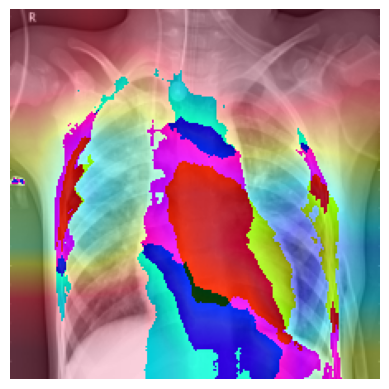

In [40]:
images, labels = next(iter(val_loader))
images = images.to(device)

heatmap = gradcam.generate(images[0].unsqueeze(0))

show_gradcam(images[0], heatmap)

In [43]:
class NeuroSymbolicLayer:
    def __init__(self, threshold=0.8):
        self.threshold = threshold

    def rule_engine(self, probs, age=None, symptoms=None, oxygen_saturation=None,
                    fever=None, cough=None, chest_pain=None, fatigue=None,
                    xray_quality=None, history_smoking=None):

        pneumonia_prob = probs[1]
        explanation = []

        # =========================
        # CNN DECISION
        # =========================
        if pneumonia_prob > self.threshold:
            decision = "PNEUMONIA"
            explanation.append("High CNN probability of infection pattern")
        else:
            decision = "NORMAL"
            explanation.append("Low CNN infection probability")

        # =========================
        # BASE CLINICAL RULES (you already had)
        # =========================
        if symptoms:
            if "fever" in symptoms and "cough" in symptoms:
                explanation.append("Fever + cough strongly correlate with pneumonia")

        if age and age > 60 and pneumonia_prob > 0.6:
            explanation.append("Elderly patient increases pneumonia risk weight")

        # =====================================================
        # 🔥 NEW 10 SYMBOLIC RULES (IMPORTANT PART)
        # =====================================================

        # 1. Oxygen saturation rule
        if oxygen_saturation is not None:
            if oxygen_saturation < 92 and pneumonia_prob > 0.5:
                explanation.append("Low oxygen saturation strengthens pneumonia suspicion")

        # 2. Chest pain rule
        if chest_pain and pneumonia_prob > 0.6:
            explanation.append("Chest pain aligns with respiratory infection likelihood")

        # 3. Fatigue rule
        if fatigue and pneumonia_prob > 0.6:
            explanation.append("Fatigue supports systemic infection pattern")

        # 4. Smoking history risk boost
        if history_smoking and pneumonia_prob > 0.5:
            explanation.append("Smoking history increases lung infection susceptibility")

        # 5. High confidence override rule
        if pneumonia_prob > 0.95:
            explanation.append("Very high CNN confidence overrides weak symptoms")

        # 6. Low confidence contradiction rule
        if pneumonia_prob < 0.3 and (fever or cough):
            explanation.append("Symptoms present but low imaging signal → recheck advised")

        # 7. Combined symptom severity rule
        if fever and cough and chest_pain and pneumonia_prob > 0.6:
            explanation.append("Multiple symptoms strongly reinforce pneumonia prediction")

        # 8. Mild case uncertainty rule
        if 0.4 < pneumonia_prob < 0.6:
            explanation.append("Borderline prediction → requires radiologist review")

        # 9. Image quality rule
        if xray_quality == "poor":
            explanation.append("Low image quality may reduce prediction reliability")

        # 10. Age-risk synergy rule
        if age and age > 65 and fever and pneumonia_prob > 0.5:
            explanation.append("Elderly + fever increases clinical suspicion strength")

        return decision, explanation

In [44]:
ns = NeuroSymbolicLayer(threshold=0.8)

probs = torch.softmax(model(images[0].unsqueeze(0)), dim=1)[0]

decision, explanation = ns.rule_engine(
    probs,
    age=65,
    symptoms=["fever", "cough"]
)

print("Decision:", decision)
print("Reasoning:")
for e in explanation:
    print("-", e)

Decision: PNEUMONIA
Reasoning:
- High CNN probability of infection pattern
- Fever + cough strongly correlate with pneumonia
- Elderly patient increases pneumonia risk weight
- Very high CNN confidence overrides weak symptoms
